# Tanager Mangrove Mapping - 02b Model Interpretation

| | |
|---|---|
| **Authors**     | Muhammad Wahyu Ramadhan, Athar Abdurrahman B., Diniyarti |
| **Competition** | Planet Tanager Open Data Competition 2026 |
| **Topic**       | Transferable Mangrove Extent Mapping Using Adaptive Spectral Thresholds |
| **Date**        | August 2026 |

---

**Scope:** Feature importance analysis for the XGBoost Tuned model trained on Sangatta.
Requires outputs from `02_classification.ipynb` (saved model + best params JSON).
Two analyses:
1. Cross-validation feature importance heatmap -- importance per fold, showing stability across folds.
2. SHAP beeswarm plot -- direction and magnitude of each feature's contribution to individual predictions.

## 0. Environment Setup

In [1]:
%%javascript
function KeepAlive() {
  document.querySelector("#top-toolbar").click();
  console.log("keep alive: " + new Date().toLocaleTimeString());
}
setInterval(KeepAlive, 60000);  // klik setiap 60 detik

<IPython.core.display.Javascript object>

In [2]:
# Install dependencies (Colab)
!pip install scikit-learn xgboost geopandas rasterio matplotlib joblib shap seaborn

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import sys
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import rasterio
import shap

# ============================================================
# Project root (adjust per environment)
# ============================================================
# Google Colab (Google Drive mounted)
ROOT = Path('/content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping')

# Local (uncomment if running locally)
# ROOT = Path('..').resolve()

DATA_PROC   = ROOT / 'data' / 'processed'
DATA_GMW    = ROOT / 'data' / 'gmw_v3'
OUT_MODELS  = ROOT / 'outputs' / 'models'
OUT_RESULTS = ROOT / 'outputs' / 'results'
OUT_FIGURES = ROOT / 'outputs' / 'figures'

sys.path.insert(0, str(ROOT))
from src.preprocessing import load_geotiff_bands, compute_all_indices
from src.classification import (
    generate_pseudo_labels,
    build_feature_matrix,
    split_data,
    load_model,
)

# ============================================================
# Scene IDs
# ============================================================
SCENES = {
    'sangatta'   : '20250302_030003_92_4001',
    'gujarat'    : '20250311_061550_53_4001',
    'elsalvador' : '20250223_165546_32_4001',
    'belize'     : '20250824_171853_67_4001',
    'belize2'    : '20250824_171857_84_4001',
    'australia'  : '20250608_014315_58_4001',
}

SITE     = 'sangatta'
SCENE_ID = SCENES[SITE]

print(f'ROOT     : {ROOT}')
print(f'SITE     : {SITE}')
print(f'SCENE_ID : {SCENE_ID}')

ROOT     : /content/drive/MyDrive/PROJECT/Planet Tanager Competition 2026/tanager-mangrove-mapping
SITE     : sangatta
SCENE_ID : 20250302_030003_92_4001


In [5]:
# ============================================================
# Reload src modules during development
# ============================================================
import importlib
import src.preprocessing  as _pre
import src.classification as _cls
importlib.reload(_pre)
importlib.reload(_cls)
from src.preprocessing import load_geotiff_bands, compute_all_indices
from src.classification import (
    generate_pseudo_labels, build_feature_matrix, split_data, load_model,
)
print('Reloaded.')

Reloaded.


## 1. Load Model + Feature Matrix

In [6]:
# ============================================================
# Indices + thresholds (same as NB02)
# ============================================================
data    = load_geotiff_bands(str(DATA_PROC), SCENE_ID, site=SITE)
indices = compute_all_indices(data)

thresh_path = OUT_RESULTS / f'thresholds_{SITE}_{SCENE_ID}.json'
with open(thresh_path) as f:
    thresholds = json.load(f)

# Candidate mask
cand_path = DATA_PROC / f'candidate_{SITE}_{SCENE_ID}.tif'
with rasterio.open(cand_path) as src:
    candidate_mask = src.read(1).astype(bool)
print(f'Candidate mask loaded : {candidate_mask.sum():,} px')

# REIP (resampled to indices grid)
from rasterio.warp import reproject, Resampling

def _resample_to_grid(src_array, src_transform, src_crs,
                      dst_shape, dst_transform, dst_crs):
    dst = np.full(dst_shape, np.nan, dtype=np.float32)
    reproject(
        source=src_array, destination=dst,
        src_transform=src_transform, src_crs=src_crs,
        dst_transform=dst_transform, dst_crs=dst_crs,
        resampling=Resampling.bilinear,
        src_nodata=np.nan, dst_nodata=np.nan,
    )
    return dst

dst_shape     = indices['NDMI'].shape
dst_transform = data['transform']
dst_crs       = data['crs']

reip_path = DATA_PROC / f'reip_{SITE}_{SCENE_ID}.tif'
with rasterio.open(reip_path) as src:
    reip_map_r = _resample_to_grid(
        src.read(1), src.transform, src.crs,
        dst_shape, dst_transform, dst_crs
    )

extra_features = {'REIP': reip_map_r}
print(f'REIP resampled : mean={np.nanmean(reip_map_r):.1f} nm')

  Bands loaded  : ['green', 'red', 'rededge', 'nir', 'swir1', 'swir2']
  CRS           : PROJCS["WGS 84 / UTM zone 50N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


Candidate mask loaded : 57,014 px


REIP resampled : mean=725.8 nm


In [7]:
# ============================================================
# Pseudo-labels + feature matrix (identical to NB02)
# ============================================================
labels = generate_pseudo_labels(indices, thresholds, candidate_mask=candidate_mask)

X, y, feature_names = build_feature_matrix(
    indices, labels, extra_features=extra_features
)
X_train, X_test, y_train, y_test = split_data(X, y)

print(f'Features : {feature_names}')
print(f'X_train  : {X_train.shape}')

  Pseudo-labels generated:
  mangrove     : 8,249 px
  non-mangrove : 489,548 px
  invalid      : 190,703 px
  (constrained to coastal candidate zone)
  Feature matrix : 497,797 samples x 9 features
  Features       : ['NDVI', 'MNDWI', 'NDMI', 'CMRI', 'NDRE', 'SAVI', 'MVI', 'EMI', 'REIP']
  Train samples  : 398,237
  Test samples   : 99,560
Features : ['NDVI', 'MNDWI', 'NDMI', 'CMRI', 'NDRE', 'SAVI', 'MVI', 'EMI', 'REIP']
X_train  : (398237, 9)


In [8]:
# ============================================================
# Load tuned XGBoost saved in NB02
# ============================================================
xgb_tuned = load_model(str(OUT_MODELS / f'xgb_tuned_{SITE}_{SCENE_ID}.joblib'))
print(f'Model loaded : xgb_tuned_{SITE}_{SCENE_ID}.joblib')

# Best hyperparameters from NB02 tuning
params_path = OUT_RESULTS / f'xgb_best_params_{SITE}_{SCENE_ID}.json'
with open(params_path) as f:
    best_params_raw = json.load(f)

# Cast numeric strings back to float/int
CAST_INT = {'max_depth', 'min_child_weight', 'n_estimators'}
best_params = {}
for k, v in best_params_raw.items():
    if k in CAST_INT:
        best_params[k] = int(float(v))
    else:
        try:
            best_params[k] = float(v)
        except ValueError:
            best_params[k] = v

print('Best params:')
for k, v in best_params.items():
    print(f'  {k:<22}: {v}')

Model loaded : xgb_tuned_sangatta_20250302_030003_92_4001.joblib
Best params:
  colsample_bytree      : 0.6987504251354405
  gamma                 : 0.3481521364198942
  learning_rate         : 0.21655847107808818
  max_depth             : 7
  min_child_weight      : 1
  n_estimators          : 539
  reg_alpha             : 0.036886947354532795
  reg_lambda            : 1.4143465009698453
  subsample             : 0.8010716092915446


## 2. Cross-Validation Feature Importance Heatmap

Re-run 5-fold stratified CV using the best hyperparameters from NB02 tuning.
For each fold, record `feature_importances_` (XGBoost gain-based) and validation F1.
The heatmap visualises importance stability across folds.
Row-normalised so values within each fold sum to 1 and are directly comparable.

In [9]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import time

N_FOLDS      = 5
N_SHAP_FOLD  = 500   # subsample per fold for SHAP computation (keep runtime low)

# scale_pos_weight mirrors NB02
n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
spw   = n_neg / n_pos
print(f'scale_pos_weight : {spw:.2f}  (neg={n_neg:,} / pos={n_pos:,})')

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_importances = []   # mean |SHAP| per fold
fold_f1s         = []
rng_fold         = np.random.RandomState(42)

for fold, (tr_idx, val_idx) in enumerate(
        skf.split(X_train, y_train), start=1):
    t0 = time.time()
    model_fold = xgb.XGBClassifier(
        **best_params,
        scale_pos_weight=spw,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist',
    )
    model_fold.fit(
        X_train[tr_idx], y_train[tr_idx],
        eval_set=[(X_train[val_idx], y_train[val_idx])],
        verbose=False,
    )

    y_pred = model_fold.predict(X_train[val_idx])
    f1     = f1_score(y_train[val_idx], y_pred)
    fold_f1s.append(f1)

    # SHAP mean |values| on a stratified subsample of the validation set
    val_pos = np.where(y_train[val_idx] == 1)[0]
    val_neg = np.where(y_train[val_idx] == 0)[0]
    n_each  = min(N_SHAP_FOLD // 2, len(val_pos), len(val_neg))
    sub_idx = np.concatenate([
        rng_fold.choice(val_pos, n_each, replace=False),
        rng_fold.choice(val_neg, n_each, replace=False),
    ])
    X_val_sub = pd.DataFrame(X_train[val_idx][sub_idx], columns=feature_names)

    explainer_fold = shap.TreeExplainer(model_fold)
    sv = explainer_fold(X_val_sub)

    sv_vals = sv.values
    if sv_vals.ndim == 3:
        sv_vals = sv_vals[:, :, 1]   # mangrove class

    mean_abs = np.abs(sv_vals).mean(axis=0)
    fold_importances.append(mean_abs)

    print(f'  Fold {fold}/{N_FOLDS}  F1={f1:.4f}  SHAP n={len(sub_idx)}  ({time.time()-t0:.0f} s)')

print(f'\nMean F1 : {np.mean(fold_f1s):.4f} +/- {np.std(fold_f1s):.4f}')

scale_pos_weight : 59.35  (neg=391,638 / pos=6,599)
  Fold 1/5  F1=0.9649  SHAP n=500  (26 s)
  Fold 2/5  F1=0.9553  SHAP n=500  (24 s)
  Fold 3/5  F1=0.9645  SHAP n=500  (25 s)
  Fold 4/5  F1=0.9635  SHAP n=500  (27 s)
  Fold 5/5  F1=0.9638  SHAP n=500  (23 s)

Mean F1 : 0.9624 +/- 0.0036


F1 per fold:
  Fold 1: 0.9649
  Fold 2: 0.9553
  Fold 3: 0.9645
  Fold 4: 0.9635
  Fold 5: 0.9638
Mean F1: 0.9624  Std: 0.0036


/tmp/ipykernel_4646/2854757325.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_base  = plt.cm.get_cmap('Oranges', 256)


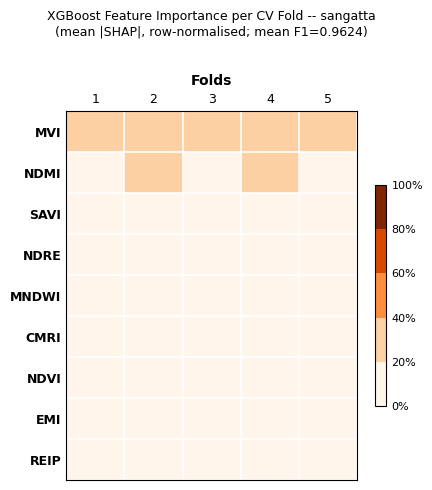

Figure saved.


In [10]:
from matplotlib.colors import BoundaryNorm

df_imp = pd.DataFrame(
    fold_importances,
    columns=feature_names,
    index=[f'Fold {i}' for i in range(1, N_FOLDS + 1)],
)

# Row-normalise within each fold, convert to %
df_imp_norm = df_imp.div(df_imp.sum(axis=1), axis=0) * 100

# Sort features by mean importance descending (top = most important)
col_order = df_imp_norm.mean().sort_values(ascending=False).index
df_plot_T = df_imp_norm[col_order].T          # features as rows, folds as cols
df_plot_T.columns = [str(i) for i in range(1, N_FOLDS + 1)]

# Discrete colorbar: 5 bins (0-20%, 20-40%, 40-60%, 60-80%, 80-100%)
boundaries = [0, 20, 40, 60, 80, 100]
cmap_base  = plt.cm.get_cmap('Oranges', 256)
norm       = BoundaryNorm(boundaries, ncolors=cmap_base.N)

fig, ax = plt.subplots(figsize=(4.5, 5))

im = ax.imshow(
    df_plot_T.values,
    aspect='auto',
    cmap=cmap_base,
    norm=norm,
    interpolation='nearest',
)

for x in np.arange(-0.5, N_FOLDS, 1):
    ax.axvline(x, color='white', linewidth=1.2)
for y in np.arange(-0.5, len(df_plot_T), 1):
    ax.axhline(y, color='white', linewidth=1.2)

ax.set_xticks(np.arange(N_FOLDS))
ax.set_xticklabels([str(i) for i in range(1, N_FOLDS + 1)], fontsize=9)
ax.set_yticks(np.arange(len(df_plot_T)))
ax.set_yticklabels(df_plot_T.index, fontsize=9, fontweight='bold')
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.tick_params(axis='both', length=0)
ax.set_xlabel('Folds', fontsize=10, fontweight='bold', labelpad=6)
ax.set_ylabel('')
ax.set_title(
    f'XGBoost Feature Importance per CV Fold -- {SITE}\n'
    f'(mean |SHAP|, row-normalised; mean F1={np.mean(fold_f1s):.4f})',
    fontsize=9, pad=28,
)

cbar = fig.colorbar(im, ax=ax, shrink=0.6, ticks=boundaries)
cbar.ax.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'], fontsize=8)
cbar.ax.tick_params(length=0)

print('F1 per fold:')
for i, f1 in enumerate(fold_f1s, 1):
    print(f'  Fold {i}: {f1:.4f}')
print(f'Mean F1: {np.mean(fold_f1s):.4f}  Std: {np.std(fold_f1s):.4f}')

plt.tight_layout()
plt.savefig(
    OUT_FIGURES / f'cv_importance_heatmap_{SITE}_{SCENE_ID}.png',
    dpi=300, bbox_inches='tight',
)
plt.show()
print('Figure saved.')

## 3. SHAP Beeswarm

SHAP (SHapley Additive exPlanations) TreeExplainer on the final XGBoost Tuned model.
Beeswarm plot shows, for each feature, how its value (colour) pushes predictions
toward mangrove (positive SHAP) or non-mangrove (negative SHAP) for individual samples.
Computed on a stratified subsample to keep runtime manageable on Colab.

In [11]:
from sklearn.utils import resample

# ============================================================
# Stratified subsample for SHAP computation
# ============================================================
N_SHAP      = 5000   # total samples (balanced mangrove / non-mangrove)
N_PER_CLASS = N_SHAP // 2

rng = np.random.RandomState(42)

idx_pos = np.where(y_test == 1)[0]
idx_neg = np.where(y_test == 0)[0]

idx_pos_s = rng.choice(idx_pos, min(N_PER_CLASS, len(idx_pos)), replace=False)
idx_neg_s = rng.choice(idx_neg, min(N_PER_CLASS, len(idx_neg)), replace=False)
idx_shap  = np.concatenate([idx_pos_s, idx_neg_s])
rng.shuffle(idx_shap)

# Wrap as DataFrame so SHAP reads column names directly
X_shap_df = pd.DataFrame(X_test[idx_shap], columns=feature_names)
print(f'SHAP background : {X_shap_df.shape}  '
      f'(mangrove={len(idx_pos_s):,} / non-mangrove={len(idx_neg_s):,})')

# TreeExplainer is exact and fast for gradient-boosted trees
explainer   = shap.TreeExplainer(xgb_tuned)
shap_values = explainer(X_shap_df)

print('SHAP values computed.')

SHAP background : (4150, 9)  (mangrove=1,650 / non-mangrove=2,500)
SHAP values computed.


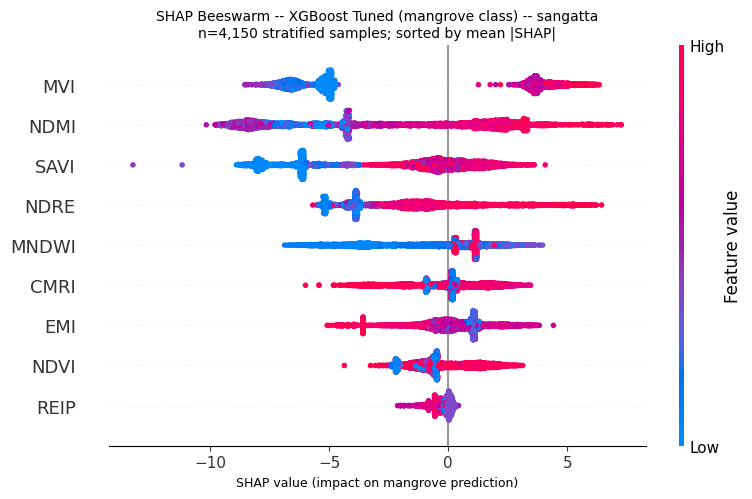

Figure saved.


In [12]:
# ============================================================
# Beeswarm plot -- mangrove class (class index 1)
# Explicit shap.Explanation with feature_names matches the
# approach in Zhao et al. (2026) official repo (Modeling.ipynb)
# ============================================================
shap_vals_raw = shap_values.values   # (n_samples, n_features, n_classes) or (n_samples, n_features)

if shap_vals_raw.ndim == 3:
    shap_vals_man = shap_vals_raw[:, :, 1]   # mangrove class
else:
    shap_vals_man = shap_vals_raw

base_val = shap_values.base_values
if hasattr(base_val, '__len__') and base_val.ndim == 2:
    base_val = base_val[:, 1]

exp = shap.Explanation(
    values=shap_vals_man,
    base_values=base_val,
    data=X_shap_df.values,
    feature_names=feature_names,
)

fig, ax = plt.subplots(figsize=(9, 6))
plt.sca(ax)

shap.plots.beeswarm(
    exp,
    max_display=len(feature_names),
    show=False,
    color_bar_label='Feature value',
)

ax.set_title(
    f'SHAP Beeswarm -- XGBoost Tuned (mangrove class) -- {SITE}\n'
    f'n={len(idx_shap):,} stratified samples; sorted by mean |SHAP|',
    fontsize=10,
)
ax.set_xlabel('SHAP value (impact on mangrove prediction)', fontsize=9)

plt.tight_layout()
plt.savefig(
    OUT_FIGURES / f'shap_beeswarm_{SITE}_{SCENE_ID}.png',
    dpi=300,
)
plt.show()
print('Figure saved.')

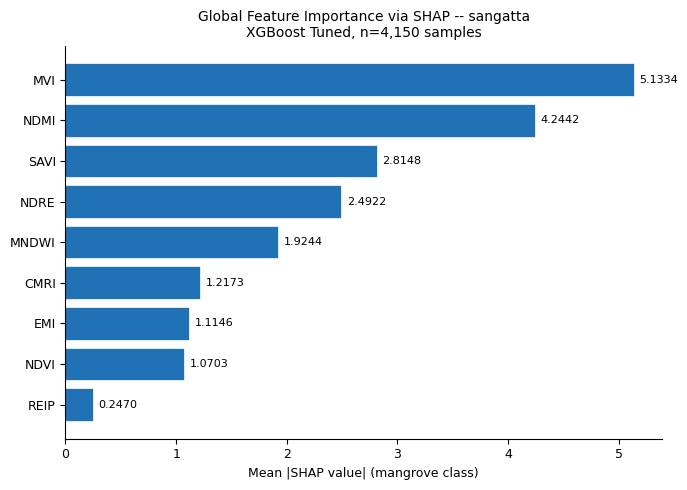

Figure saved.


In [13]:
# ============================================================
# Mean |SHAP| bar chart -- compact summary for publication
# ============================================================
mean_abs_shap = np.abs(exp.values).mean(axis=0)
df_shap = pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_abs_shap})
df_shap = df_shap.sort_values('mean_abs_shap', ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(
    df_shap['feature'], df_shap['mean_abs_shap'],
    color='#2171b5', edgecolor='white', linewidth=0.5,
)
for bar, val in zip(bars, df_shap['mean_abs_shap']):
    ax.text(
        val + mean_abs_shap.max() * 0.01, bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}', va='center', ha='left', fontsize=8,
    )
ax.set_xlabel('Mean |SHAP value| (mangrove class)', fontsize=9)
ax.set_title(
    f'Global Feature Importance via SHAP -- {SITE}\n'
    f'XGBoost Tuned, n={len(idx_shap):,} samples',
    fontsize=10,
)
ax.tick_params(labelsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(
    OUT_FIGURES / f'shap_mean_bar_{SITE}_{SCENE_ID}.png',
    dpi=300,
)
plt.show()
print('Figure saved.')